In [2]:
'''This file is meant to be a demonstartion of how the different modules in detector_cuts work'''


import pandas as pd
from timesoft.detector_cuts import *
df=pd.read_csv('iteration24.csv') #Sukhman's list
df2=pd.DataFrame(np.loadtxt('20221212_noisepsd_nonPID.txt.csv',delimiter=',')) #Dongwoo's callibrations
df2.iloc[:,0]=df2.iloc[:,0].apply(lambda x: int(x))
df2.iloc[:,1]=df2.iloc[:,1].apply(lambda x: int(x))
df2.rename(columns= {0: 'x', 1:'f', 2: 'NEI', 3: 'Gains'}, inplace = True)

In [3]:
good_detectors, detectors_DC, df2= intersection(df, df2)
print(good_detectors)

[(1, 8), (1, 10), (1, 14), (1, 15), (2, 9), (2, 11), (2, 12), (2, 13), (2, 14), (2, 50), (3, 9), (3, 11), (3, 13), (3, 15), (4, 10), (4, 50), (4, 53), (4, 54), (5, 3), (5, 4), (5, 6), (5, 11), (5, 49), (5, 50), (6, 3), (6, 9), (6, 10), (6, 23), (6, 50), (6, 52), (6, 53), (6, 54), (6, 55), (7, 8), (7, 9), (7, 10), (7, 22), (7, 50), (7, 53), (7, 55), (8, 8), (8, 9), (8, 10), (8, 11), (8, 14), (9, 10), (9, 11), (9, 12), (9, 13), (9, 14), (9, 49), (9, 50), (9, 51), (10, 9), (10, 10), (10, 11), (10, 12), (10, 14), (10, 51), (10, 53), (12, 25), (12, 27), (12, 32), (12, 33), (13, 26), (14, 24), (14, 26), (14, 49)]


In [4]:
detector_numbers_list= RMS_filter(good_detectors,3)
print(detector_numbers_list)

[(1, 8), (1, 10), (1, 14), (1, 15), (2, 9), (2, 11), (2, 12), (2, 13), (2, 14), (2, 50), (3, 9), (3, 11), (3, 13), (3, 15), (4, 10), (4, 50), (4, 53), (4, 54), (5, 3), (5, 4), (5, 6), (5, 11), (5, 49), (5, 50), (6, 3), (6, 9), (6, 10), (6, 23), (6, 50), (6, 52), (6, 53), (6, 54), (6, 55), (7, 8), (7, 9), (7, 10), (7, 22), (7, 50), (7, 53), (7, 55), (8, 8), (8, 9), (8, 11), (8, 14), (9, 10), (9, 11), (9, 12), (9, 13), (9, 14), (9, 49), (9, 50), (9, 51), (10, 9), (10, 10), (10, 11), (10, 12), (10, 14), (10, 51), (10, 53), (12, 25), (12, 27), (12, 32), (12, 33), (13, 26), (14, 24), (14, 26), (14, 49)]


C:\Users\IBRAHIM SHEHZAD\Anaconda3\lib\site-packages\pandas\compat\_optional.py:117: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if distutils.version.LooseVersion(version) < minimum_version:
C:\Users\IBRAHIM SHEHZAD\Anaconda3\lib\site-packages\setuptools\_distutils\version.py:346: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


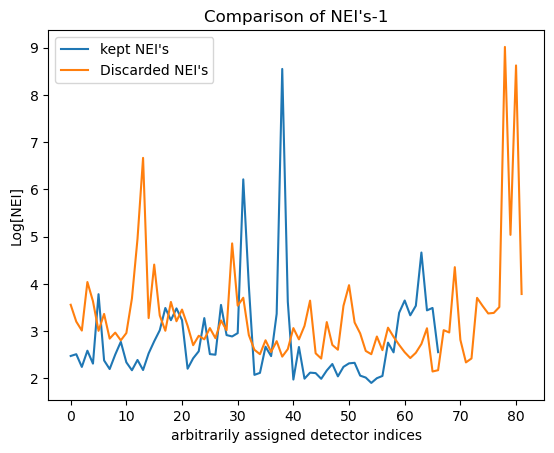

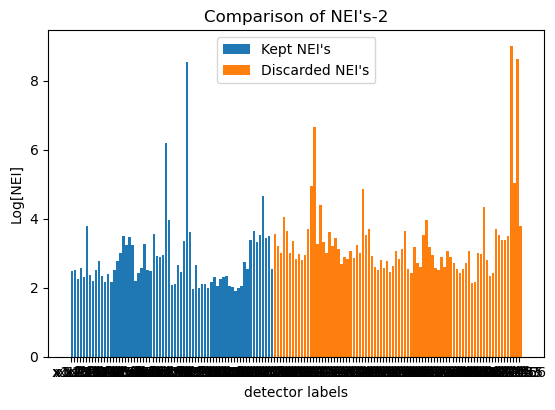

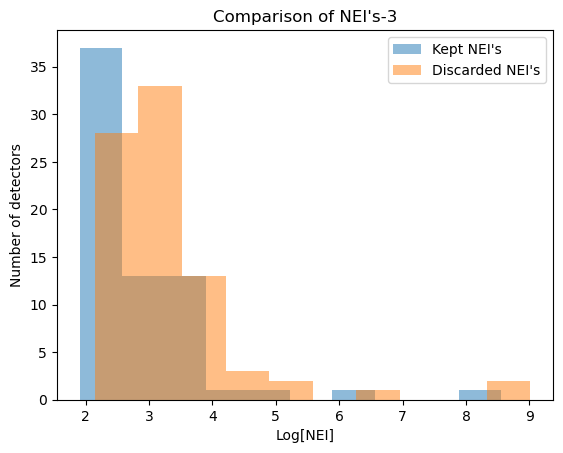

In [5]:
ldiscarded=discarded(df2, detector_numbers_list)

xd, yd=NEIdiscarded(ldiscarded, df2)

xk, yk = NEIkept(detector_numbers_list, df2)

det_plots(xk,xd,yk,yd)

#suggestion on what to do to the x-axis labels are welcome

In [6]:
X_pca, X_orig, det_x,detector_sublist,z=xwise_pca(1,3,detector_numbers_list)

C:\Users\IBRAHIM SHEHZAD\AppData\Local\Temp\ipykernel_25476\1150920666.py:1: RankWarning: Polyfit may be poorly conditioned
  X_pca, X_orig, det_x,detector_sublist,z=xwise_pca(1,3,detector_numbers_list)


C:\Users\IBRAHIM SHEHZAD\Downloads\TIME-analysis-is-dev\timesoft\detector_cuts\PCA_analysis.py:141: RankWarning: Polyfit may be poorly conditioned
  X_pca,X_orig, det_x,detector_sublist_det_x,z=xwise_pca(det_x,n_pca,detector_numbers_list)


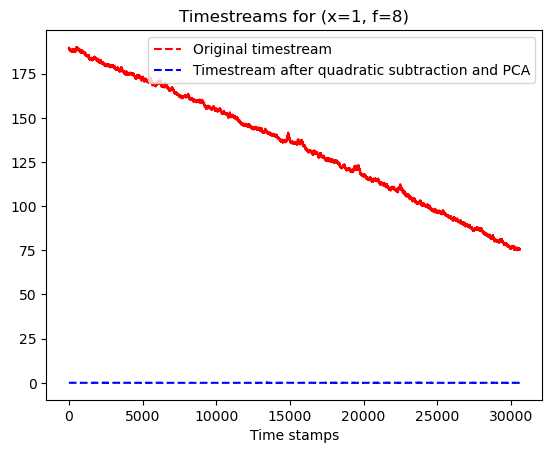

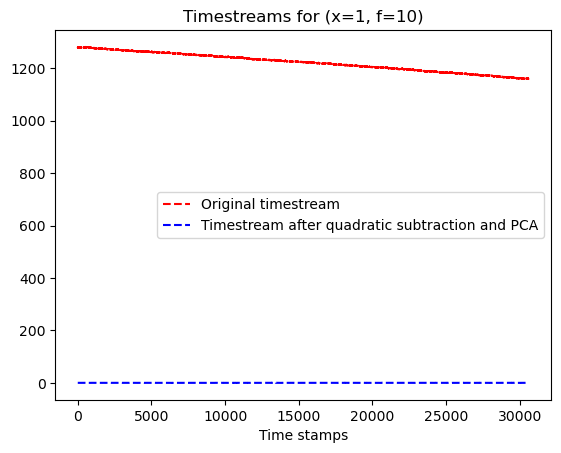

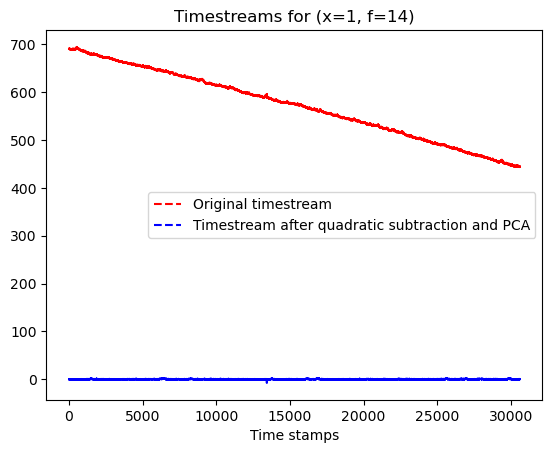

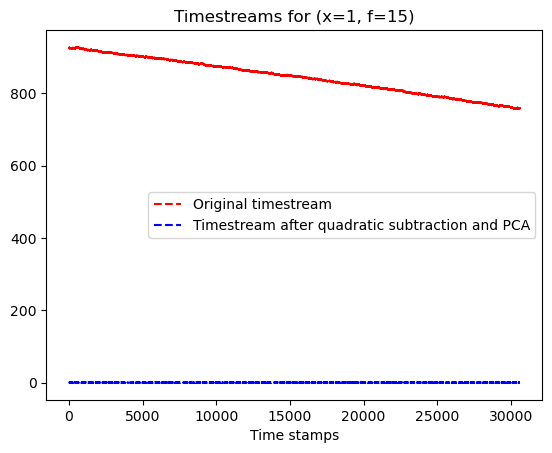

In [7]:
timestream_comparison(det_x, detector_numbers_list)

C:\Users\IBRAHIM SHEHZAD\Downloads\TIME-analysis-is-dev\timesoft\detector_cuts\PCA_analysis.py:184: RankWarning: Polyfit may be poorly conditioned
  X_pca,X_orig, det_x,detector_sublist_det_x,z=xwise_pca(det_x,n_pca,detector_numbers_list)


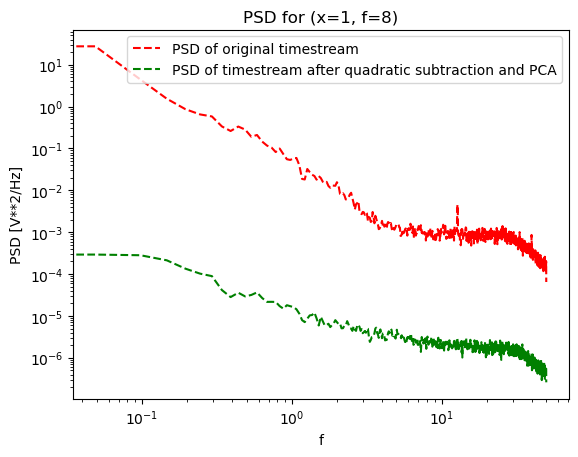

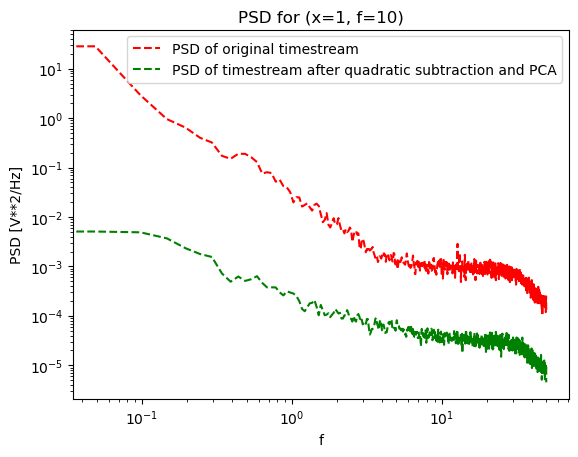

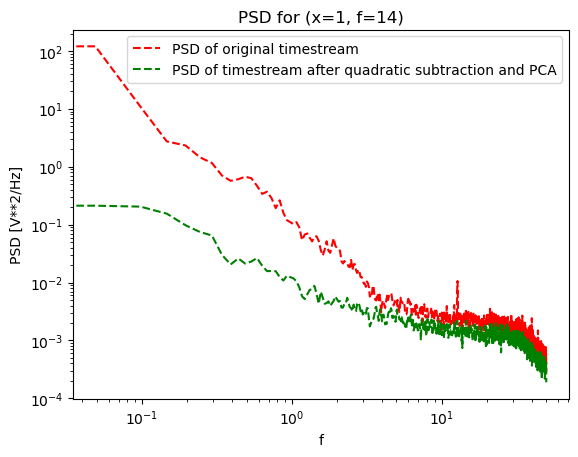

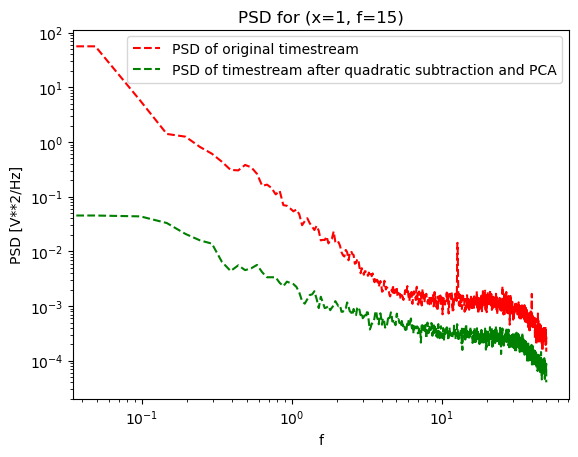

In [8]:
#Welch
signal_rate=100
nperseg=2*1024
func= scipy.signal.welch
power_spectrum(det_x, detector_numbers_list, func, signal_rate,'hann', nperseg)

C:\Users\IBRAHIM SHEHZAD\Downloads\TIME-analysis-is-dev\timesoft\detector_cuts\PCA_analysis.py:184: RankWarning: Polyfit may be poorly conditioned
  X_pca,X_orig, det_x,detector_sublist_det_x,z=xwise_pca(det_x,n_pca,detector_numbers_list)


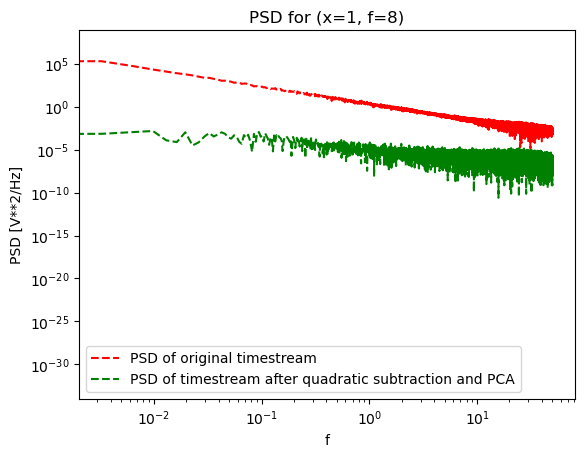

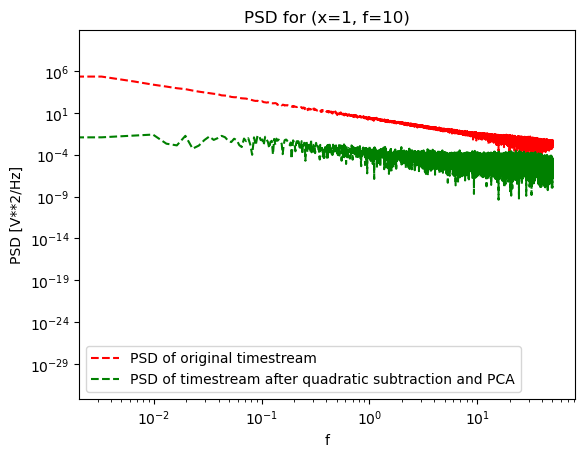

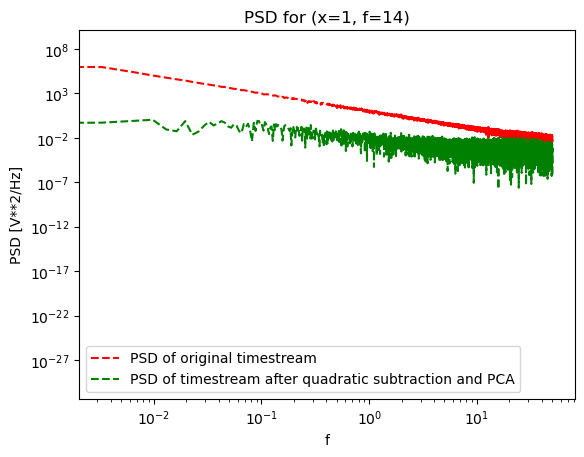

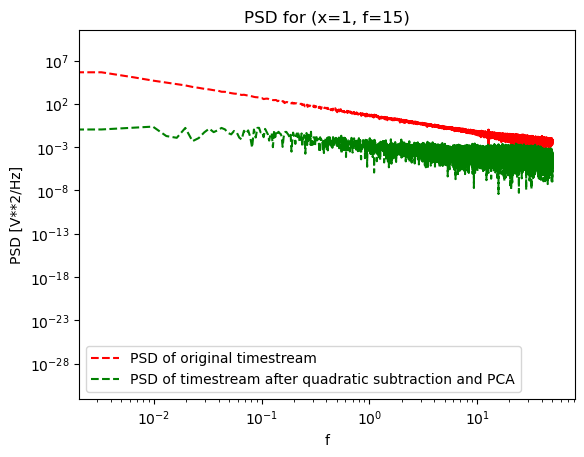

In [9]:
#spec1D
from timesoft.powspec import *
signal_rate=100
func= spec1D
power_spectrum(det_x, detector_numbers_list, func, signal_rate)